In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn
from collections import Counter

# Download latest version
path = kagglehub.dataset_download("jacksondivakarr/student-classification-dataset")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\jacksondivakarr\student-classification-dataset\versions\1


In [2]:
df = pd.read_csv(path+'\\student.csv')
df

,Unnamed: 0,Id,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,0,5001,21,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,1,5002,20,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,2,5003,21,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,3,5004,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,4,5005,22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,140,5141,22,Female,State,50%,Yes,Yes,Private,0,Always,No,Yes,No,Yes,CC
141,141,5142,18,Female,State,75%,No,No,Private,0,Never,No,Yes,Yes,No,CC
142,142,5143,18,Female,Private,75%,No,No,Private,0,Always,Yes,No,No,No,AA
143,143,5144,22,Female,State,75%,Yes,Yes,Bus,12,Sometimes,No,Yes,No,Yes,CB


In [3]:
df3 = df

df3 = df3.drop(['Unnamed: 0', 'Id'], axis = 1)
df3['State_School'] = df3['High_School_Type'].map({'State': 1}).fillna(0)
df3['Private_School'] = df3['High_School_Type'].map({'Private': 1}).fillna(0)
df3['Other_School'] = df3['High_School_Type'].map({'Other': 1}).fillna(0)
df3 = df3.drop(['High_School_Type'], axis = 1)
df3['Sex'] = df3['Sex'].map({'Male': 1}).fillna(0)
df3['Scholarship'] = df3['Scholarship'].map({'50%': 50, '75%': 75, '100%': 100, '25%': 25}).fillna(50)
df3['Additional_Work'] = df3['Additional_Work'].map({'Yes': 1}).fillna(0)
df3['Sports_activity'] = df3['Sports_activity'].map({'Yes': 1}).fillna(0)
df3['Transportation'] = df3['Transportation'].map({'Private': 1}).fillna(0)
df3['Reading'] = df3['Reading'].map({'Yes': 1}).fillna(0)
df3['Notes'] = df3['Notes'].map({'Yes': 1}).fillna(0)
df3['Listening_in_Class'] = df3['Listening_in_Class'].map({'Yes': 1}).fillna(0)
df3['Project_work'] = df3['Project_work'].map({'Yes': 1}).fillna(0)
df3['Grade'] = df3['Grade'].map({'Fail': 0, 'DD': 1, 'DC': 2, 'CC': 3, 'CB': 4, 'BB': 5, 'BA': 6, 'AA': 7}).fillna(0)
df3['Attendance'] = df3['Attendance'].map({'Always': 1, 'Sometimes': 0.5, 'Never': 0}).fillna(0)

df3

,Student_Age,Sex,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade,State_School,Private_School,Other_School
0,21,1.0,50.0,1.0,0.0,1.0,0,1.0,1.0,1.0,0.0,0.0,7,0.0,0.0,1.0
1,20,1.0,50.0,1.0,0.0,1.0,0,1.0,1.0,0.0,1.0,1.0,7,0.0,0.0,1.0
2,21,1.0,50.0,0.0,0.0,1.0,2,0.0,0.0,0.0,0.0,1.0,7,1.0,0.0,0.0
3,18,0.0,50.0,1.0,0.0,0.0,2,1.0,0.0,1.0,0.0,0.0,7,0.0,1.0,0.0
4,22,1.0,50.0,0.0,0.0,0.0,12,1.0,1.0,0.0,1.0,1.0,7,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,22,0.0,50.0,1.0,1.0,1.0,0,1.0,0.0,1.0,0.0,1.0,3,1.0,0.0,0.0
141,18,0.0,75.0,0.0,0.0,1.0,0,0.0,0.0,1.0,1.0,0.0,3,1.0,0.0,0.0
142,18,0.0,75.0,0.0,0.0,1.0,0,1.0,1.0,0.0,0.0,0.0,7,0.0,1.0,0.0
143,22,0.0,75.0,1.0,1.0,0.0,12,0.5,0.0,1.0,0.0,1.0,4,1.0,0.0,0.0


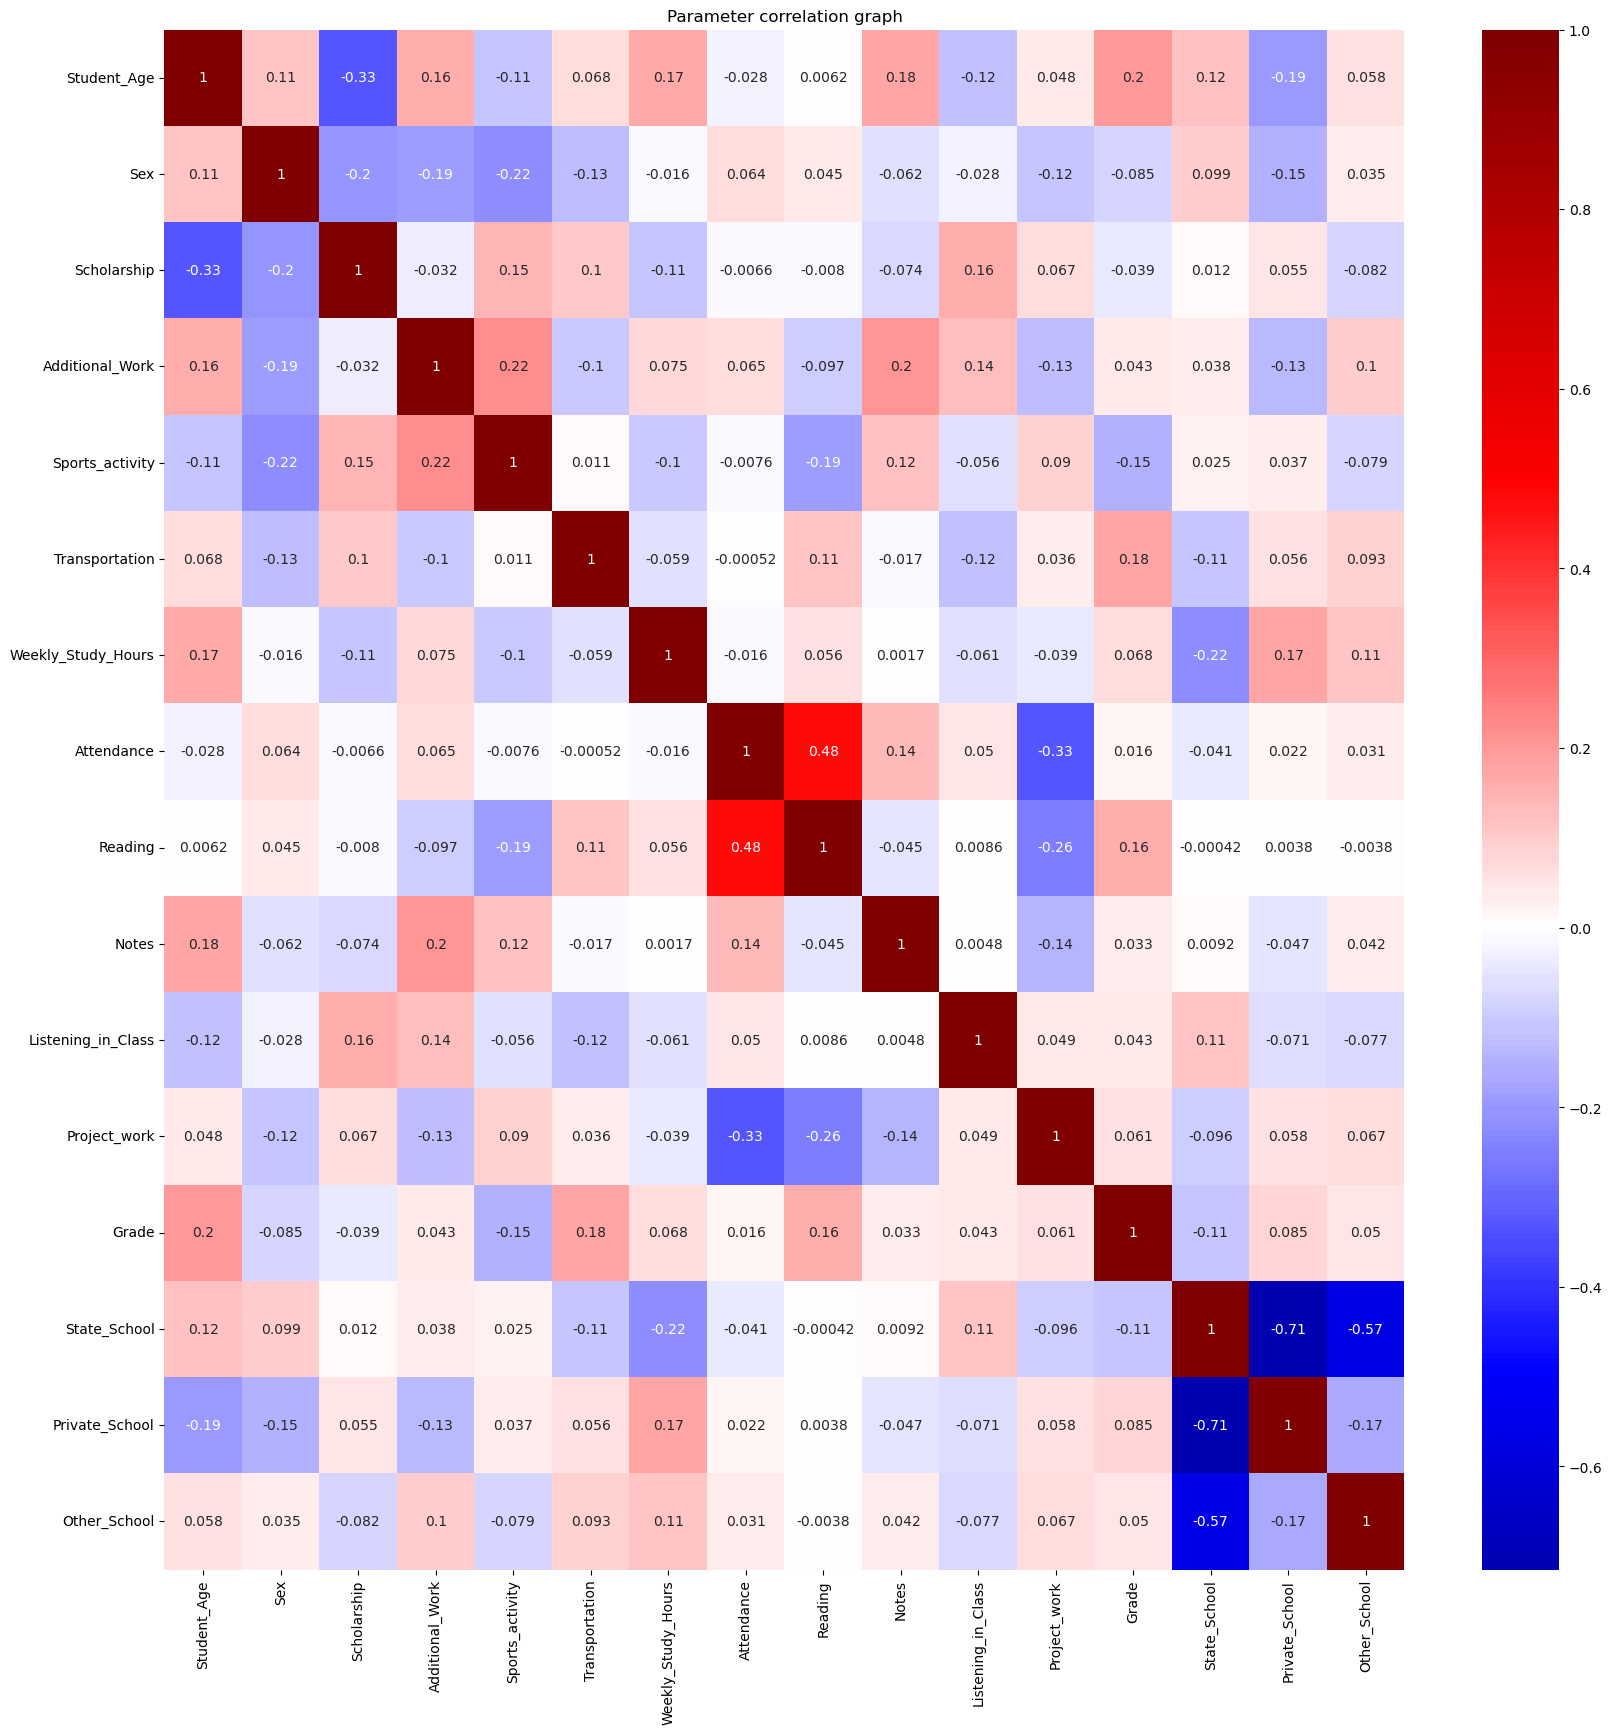

In [4]:
plt.figure(figsize=(20, 20))
seaborn.heatmap(df3.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

x = df3.drop(['Grade'], axis = 1).to_numpy()
y = df3['Grade'].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.05, random_state=42)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import  cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits = 6, random_state = 42, shuffle = True)

param_dist = {
    'n_estimators': [10, 20, 50, 100, 150, 200, 250],
    'max_depth': [4, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [2, 4, 6, 8, 10, 15],
}

rf_search = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_search,
    param_distributions = param_dist,
    n_iter = 100,  # Проверяем 100 случайных комбинаций
    cv = kf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(x, y)

print(f"\nЛучшие параметры: {random_search.best_params_}")
print(f"Лучший CV accuracy: {random_search.best_score_:.4f}")

Fitting 6 folds for each of 100 candidates, totalling 600 fits

Лучшие параметры: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 15}
Лучший CV accuracy: 0.2414


In [7]:
# лучшие параметры
rfc = RandomForestClassifier(max_depth = 15, random_state = 42, min_samples_leaf = 4, n_estimators = 100, min_samples_split = 10).fit(x_train, y_train)

print('accuracy для случайного леса для выборки обучающей / тестовой: ', round(rfc.score(x_train, y_train), 3), ' / ', round(rfc.score(x_test, y_test), 3))

clf_score_val = list(map(lambda x: round(float(x), 3), cross_val_score(rfc, x, y, cv = kf)))

print('accuracy по k-fold разложениям для случайного леса: \t', clf_score_val)
print("для случайного леса: \t\t\t\t\tточность %0.2f со стандартным отклонением %0.2f" % (np.array(clf_score_val).mean(), np.array(clf_score_val).std()))

accuracy для случайного леса для выборки обучающей / тестовой:  0.642  /  0.375
accuracy по k-fold разложениям для случайного леса: 	 [0.24, 0.292, 0.208, 0.167, 0.167, 0.375]
для случайного леса: 					точность 0.24 со стандартным отклонением 0.07


In [17]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping
import neptune
from neptune.integrations.tensorflow_keras import NeptuneCallback

grid_params = {"lr": [1e-4, 5e-4, 5e-5], "ea_epochs": [ 50, 100, 150], "batch_size": [ 4, 8, 16], "n_num": [4, 8, 12], "val_sp": [0.05, 0.1]}

for lr in grid_params["lr"]:
    for ea_epochs in grid_params["ea_epochs"]:
        for batch_size in grid_params["batch_size"]:
            for n_num in grid_params["n_num"]:
                for val_sp in grid_params["val_sp"]:
                    run = neptune.init_run(
                        project="test-lab/Nikita-Klimkovich",
                        api_token="1eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJkZjQ3YjY1Mi05MWM5LTRlZmYtOGNkMC05MmJjNDE2OGI1YWUifQ==",
                        )  # your credentials
                    
                    params = {"lr": lr, "ea_epochs": ea_epochs, "batch_size": batch_size, "n_num": n_num, "val_sp": val_sp}
                    run["parameters"] = params

                    model = keras.Sequential([
                        keras.layers.Dense(params["n_num"], input_shape=(x_train.shape[1],), activation='sigmoid'),
                        keras.layers.Dense(params["n_num"], activation='sigmoid'),
                        keras.layers.Dense(8, activation='softmax')
                    ])

                    model.compile(  
                                    optimizer = keras.optimizers.Adam(learning_rate = params["lr"]),
                                    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                                    metrics = ['accuracy']
                                    )

                    early_stopping = EarlyStopping(
                                                    monitor='val_loss',
                                                    patience = params["ea_epochs"],
                                                    verbose = 0,
                                                    restore_best_weights = True, #смотрим относительно лучшего результата, а не последнего
                                                    )

                    neptune_cbk = NeptuneCallback(run=run, base_namespace="training")

                    model.fit(
                            x = x_train,
                            y = y_train,
                            batch_size = params["batch_size"],
                            epochs = 1000,
                            verbose = 0,
                            callbacks = [early_stopping, neptune_cbk], 
                            shuffle=True,
                            validation_split = params["val_sp"]
                            )

                    eval_metrics = model.evaluate(x_test, y_test, verbose=0)
                    for j, metric in enumerate(eval_metrics):
                        run["eval/{}".format(model.metrics_names[j])] = metric

                    run.stop()
#----листаем вниз----------

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-64


D:\zmei\Lib\site-packages\neptune\internal\utils\git.py:71: UserWarning: GitPython could not be initialized
  warnings.warn("GitPython could not be initialized")
D:\zmei\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 788 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 788 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-64/metadata
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-65


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 127 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 127 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-65/metadata
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-66


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 322 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 322 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-66/metadata
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-67


...

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 82 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 82 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-221/metadata
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-222


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 32 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 32 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-222/metadata
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-223


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 467 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 467 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-223/metadata
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-224


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 362 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 362 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-224/metadata
[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-225


[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Waiting for the remaining 437 operations to synchronize with Neptune. Do not kill this process.
[neptune] [info   ] All 437 operations synced, thanks for waiting!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/test-lab/Nikita-Klimkovich/e/NIK-225/metadata


In [ ]:
#по графикам neptune лучший результат на 156 схеме (отсчет от 64)

#batch_size=4
#ea_epochs=150
#lr=0.0005
#n_num=8
#val_sp=0.05

In [22]:
#---из neptune---
#batch_size=4
#ea_epochs=150
#lr=0.0005
#n_num=8
#val_sp=0.05

model = keras.Sequential([
    keras.layers.Dense(8, input_shape=(x_train.shape[1],), activation='sigmoid'),
    keras.layers.Dense(8, activation='sigmoid'),
    keras.layers.Dense(8, activation='softmax')
])

model.compile(  
                optimizer = keras.optimizers.Adam(learning_rate = 0.0005),
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics = ['accuracy']
                )

early_stopping = EarlyStopping(
                    monitor='val_loss',
                    patience = 150,
                    verbose = 0,
                    restore_best_weights = True, #смотрим относительно лучшего результата, а не последнего
                    )

model.fit(
        x = x_train,
        y = y_train,
        batch_size = 4,
        epochs = 1000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle=True,
        validation_split = 0.05
        )

train_loss, train_r2 = model.evaluate(x_train, y_train)
test_loss, test_r2 = model.evaluate(x_test, y_test)
print('\nдля нейронной сети accuracy для обучающей \ тестовой выборки:', train_r2, ' \ ', test_r2)

D:\zmei\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4380 - loss: 1.5073 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1250 - loss: 2.5348

для нейронной сети accuracy для обучающей \ тестовой выборки: 0.43795621395111084  \  0.125
